We define nine discourse categories capturing different forms of collective response, including sympathy, information sharing, accusation, and institutional discussion. These are tracked across four temporal phases following an incident (acute, active, absorbed, recovery), allowing us to study how discourse evolves over time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.special import logsumexp
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 9})

# ── Category definitions ────────────────────────────────────────────────────
CATEGORY_ORDER = ["S1","S2","S3","S4","S5","S6","S7","S8","S9"]
CATEGORY_LABELS = {
    "S1": "Sympathy & Support",
    "S2": "Information Sharing",
    "S3": "Speculation / Cause",
    "S4": "Accusation / Blame",
    "S5": "Mobilization / Action",
    "S6": "Indifference / Low-effort",
    "S7": "Irrelevant",
    "S8": "Personal Reflection",
    "S9": "Institutional / Policy",
}
N_CATS = len(CATEGORY_ORDER)

PHASE_ORDER = ["acute", "active", "absorbed", "recovery"]
PHASE_DAYS  = {"acute": "0–3d", "active": "4–14d",
               "absorbed": "15–30d", "recovery": "31d+"}

COLORS = sns.color_palette("tab10", n_colors=N_CATS)

print("Setup complete.")
print(f"Tracking {N_CATS} response categories across {len(PHASE_ORDER)} time phases.")


Setup complete.
Tracking 9 response categories across 4 time phases.


The dataset consists of approximately 3,800 Reddit comments distributed across multiple institutions. IIT Kharagpur, IIT Kanpur, and IIT Bombay contribute the largest share of discourse, while others such as IIT Delhi and VIT have smaller representation. This imbalance should be kept in mind when interpreting results.

Assigns a reference date (anchor) per institution
Computes:
days_since_incident
time_phase

Each institution’s discourse is aligned relative to a key incident date (identified via peak activity). This converts absolute timestamps into a relative timeline, enabling meaningful comparison of discourse evolution across institutions.

Incident salience is modeled as an exponentially decaying function of time, reflecting the natural decline in attention following major events. This variable later influences how discourse transitions between behavioral states.

X
t	​
=e
−λ⋅t

(decaying attention over time)

In [12]:
# ── Load categorised data ───────────────────────────────────────────────────
df_raw = pd.read_csv("/content/reddit_categorised.csv")
df_raw["datetime"] = pd.to_datetime(df_raw["created_utc"], unit="s")
df_raw["institution"] = df_raw["institution"].astype(str).str.strip()

print("Columns:", df_raw.columns.tolist())
print(f"Total comments: {len(df_raw):,}")
print()
print("Comments per institution:")
print(df_raw["institution"].value_counts().to_string())

# ── Incident anchors ─────────────────────────────────────────────────────────
# Identified from weekly spike analysis (highest activity week per institution).
# These represent the week when the suicide event peaked on Reddit.
INCIDENT_ANCHORS = {
    "BITS":          pd.Timestamp("2025-03-03"),
    "IIT Bombay":    pd.Timestamp("2026-02-02"),
    "IIT Delhi":     pd.Timestamp("2026-03-09"),
    "IIT Kanpur":    pd.Timestamp("2025-12-29"),
    "IIT Kharagpur": pd.Timestamp("2026-04-13"),
    "VIT":           pd.Timestamp("2025-07-17"),
}

# ── Build incident-anchored dataset ─────────────────────────────────────────
WINDOW_BEFORE = 7    # days before spike to include (pre-incident chatter)
WINDOW_AFTER  = 180  # days after spike to include

rows = []
for inst, anchor in INCIDENT_ANCHORS.items():
    grp = df_raw[df_raw["institution"] == inst].copy()
    for _, row in grp.iterrows():
        days = (row["datetime"] - anchor).total_seconds() / 86400
        if -WINDOW_BEFORE <= days <= WINDOW_AFTER:
            row2 = row.copy()
            row2["incident_id"]         = inst
            row2["anchor_date"]         = anchor
            row2["days_since_incident"] = days
            rows.append(row2)

df = pd.DataFrame(rows).reset_index(drop=True)

# Phase bins
bins   = [-WINDOW_BEFORE - 0.01, 3, 14, 30, WINDOW_AFTER + 1]
labels = PHASE_ORDER
df["time_phase"] = pd.cut(df["days_since_incident"], bins=bins, labels=labels)
df["time_phase"] = pd.Categorical(df["time_phase"], categories=PHASE_ORDER, ordered=True)

# Incident salience
lam = np.log(2) / 7.0
df["incident_salience"] = np.exp(-lam * df["days_since_incident"].clip(lower=0))

print(f"\nIncident-anchored dataset: {len(df):,} comments")
print()
print("Comments per incident × phase:")
print(df.groupby(["incident_id","time_phase"], observed=True).size().unstack(fill_value=0).to_string())


Columns: ['comment_id', 'parent_id', 'author', 'body', 'score', 'created_utc', 'institution', 'topic_id', 'category_code', 'category_label', 'datetime']
Total comments: 3,798

Comments per institution:
institution
IIT Kharagpur    1020
Unknown           691
IIT Kanpur        678
IIT Bombay        618
BITS              366
VIT               266
IIT Delhi         159

Incident-anchored dataset: 2,297 comments

Comments per incident × phase:
time_phase     acute  active  absorbed  recovery
incident_id                                     
BITS               0     124         0        66
IIT Bombay       158     120        12         0
IIT Delhi          0     114         0         0
IIT Kanpur       333       0        66        87
IIT Kharagpur      0     951         0         0
VIT              134      18         0       114


In [13]:
print(df.shape)
print(df['institution'].value_counts())

(2297, 16)
institution
IIT Kharagpur    951
IIT Kanpur       486
IIT Bombay       290
VIT              266
BITS             190
IIT Delhi        114
Name: count, dtype: int64


The dataset is partitioned into North and South institutions to enable comparative analysis. Both regions are well represented, allowing for meaningful comparison of discourse patterns.

In [14]:
#Region mapping

NORTH = ["IIT Delhi", "IIT Kanpur", "IIT Kharagpur"]
SOUTH = ["IIT Bombay", "VIT", "BITS", "Unknown"]

def map_region(inst):
    inst = str(inst).strip()
    if inst in NORTH:
        return "north"
    elif inst in SOUTH:
        return "south"
    else:
        return "other"

df['region'] = df['institution'].apply(map_region)

print(df['region'].value_counts())

region
north    1551
south     746
Name: count, dtype: int64


In [15]:
df = df[df['region'].isin(['north', 'south'])]
print(df.shape)

(2297, 17)


In [16]:
if 'region' not in df.columns:
    # Region mapping (copied from previous cell KElH5_6VUdPP)
    NORTH = ["IIT Delhi", "IIT Kanpur", "IIT Kharagpur"]
    SOUTH = ["IIT Bombay", "VIT", "BITS", "Unknown"]

    def map_region(inst):
        inst = str(inst).strip()
        if inst in NORTH:
            return "north"
        elif inst in SOUTH:
            return "south"
        else:
            return "other"

    df['region'] = df['institution'].apply(map_region)

df = df[df['region'].isin(['north', 'south'])]
print("After filtering:", df.shape)

After filtering: (2297, 17)


In [17]:
CATEGORY_ORDER = ["S1","S2","S3","S4","S5","S6","S7","S8","S9"]

CATEGORY_LABELS = {
    "S1":"Sympathy & Support",
    "S2":"Information Sharing",
    "S3":"Speculation",
    "S4":"Accusation / Blame",
    "S5":"Mobilization",
    "S6":"Indifference",
    "S7":"Irrelevant",
    "S8":"Personal Reflection",
    "S9":"Institutional Policy"
}

PHASE_ORDER = ["acute","active","absorbed","recovery"]
PHASE_BINS = [-7, 3, 14, 30, 90]
PHASE_LABELS = PHASE_ORDER

N_CATS = len(CATEGORY_ORDER)

Assigns a reference date (anchor) per institution

Computes:
days_since_incident
time_phase


Each institution’s discourse is aligned relative to a key incident date (identified via peak activity). This converts absolute timestamps into a relative timeline, enabling meaningful comparison of discourse evolution across institutions.

In [18]:
# Anchor = peak activity date per institution
anchors = (
    df.groupby('institution')['datetime']
      .agg(lambda x: x.value_counts().idxmax())
)

df['anchor_date'] = df['institution'].map(anchors)

df['days_since_incident'] = (
    (df['datetime'] - df['anchor_date']).dt.total_seconds() / 86400
)

df['time_phase'] = pd.cut(
    df['days_since_incident'],
    bins=PHASE_BINS,
    labels=PHASE_LABELS
)

In [19]:
lam = np.log(2)/7
df['incident_salience'] = np.exp(-lam * df['days_since_incident'].clip(lower=0))

Proportion Computation
Computes:
proportion= total comments in phase / category count
	​

We normalize discourse counts into proportions to control for differences in activity levels across institutions and phases. This ensures that comparisons reflect relative emphasis on discourse types rather than volume differences.

In [20]:
prop = (
    df.groupby(['region','institution','time_phase','category_code'])
      .size()
      .reset_index(name='count')
)

phase_totals = (
    df.groupby(['region','institution','time_phase'])
      .size()
      .reset_index(name='total')
)

prop = prop.merge(phase_totals)
prop['proportion'] = prop['count'] / prop['total']

What the code does

Converts each institution into:
a sequence of category distributions (per phase)
corresponding salience values

North: 3 sequences
South: 3 sequences

Each institution is represented as a temporal sequence of discourse distributions, forming the input to the IOHMM. Only institutions with sufficient data across multiple phases are retained.

In [21]:
def build_sequences(df, prop_df):
    sequences, intensities, names = [], [], []

    mean_sal = (
        df.groupby(['institution','time_phase'])['incident_salience']
          .mean().reset_index()
    )

    for inst in df['institution'].unique():
        seq, inten = [], []

        for phase in PHASE_ORDER:
            sub = prop_df[
                (prop_df['institution']==inst) &
                (prop_df['time_phase']==phase)
            ]

            sal = mean_sal[
                (mean_sal['institution']==inst) &
                (mean_sal['time_phase']==phase)
            ]

            # Skip this phase if there's no data or total comments are zero
            if len(sub) == 0 or len(sal) == 0 or (not sub.empty and sub['total'].iloc[0] == 0):
                continue

            vec = np.zeros(N_CATS)

            for _, row in sub.iterrows():
                if row['category_code'] in CATEGORY_ORDER:
                    idx = CATEGORY_ORDER.index(row['category_code'])
                    vec[idx] = row['proportion']

            vec = vec/(vec.sum()+1e-9)

            seq.append(vec)
            inten.append(sal['incident_salience'].values[0])

        if len(seq)>=2:
            sequences.append(np.array(seq))
            intensities.append(np.array(inten))
            names.append(inst)

    return sequences, intensities, names

What the code does

Defines:
latent states
transitions depending on salience
emission probabilities (category distributions)


The IOHMM models discourse as arising from latent behavioral states, where transitions between states depend on incident salience. This allows us to capture both temporal dynamics and the influence of event intensity.

In [23]:
# Re-loading the complete IOHMM class definition
import numpy as np
from scipy.special import logsumexp
from scipy.optimize import minimize

class IOHMM:
    def __init__(self, n_states, n_obs, random_state=42):
        self.K = n_states
        self.D = n_obs
        self.rng = np.random.default_rng(random_state)

    def _init_params(self):
        K, D = self.K, self.D
        log_pi = np.zeros(K)
        W = self.rng.normal(0, 0.3, (K, K))
        v = self.rng.normal(0, 0.3, (K, K))
        log_B = self.rng.normal(0, 0.3, (K, D))
        return log_pi, W, v, log_B

    def _transition(self, W, v, x):
        logits = W + v * x
        logits = logits - logits.max(axis=1, keepdims=True)
        A = np.exp(logits)
        A /= A.sum(axis=1, keepdims=True)
        return A

    def _emission_logprob(self, log_B, obs):
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        return obs @ log_B_norm.T

    def _forward(self, log_pi, W, v, log_B, seq, inten):
        T = len(seq)
        K = self.K

        alpha = np.full((T, K), -np.inf)
        alpha[0] = log_pi + self._emission_logprob(log_B, seq[0])

        for t in range(1, T):
            A = self._transition(W, v, inten[t])
            logA = np.log(A + 1e-12)

            for j in range(K):
                alpha[t, j] = logsumexp(alpha[t-1] + logA[:, j]) + \
                              self._emission_logprob(log_B, seq[t])[j]

        return logsumexp(alpha[-1]), alpha

    def fit(self, sequences, intensities, n_restarts=3):
        best_ll = -np.inf
        best_params = None

        for _ in range(n_restarts):
            log_pi, W, v, log_B = self._init_params()

            def loss(flat_params):
                idx = 0
                K, D = self.K, self.D

                log_pi_ = flat_params[idx:idx+K]; idx+=K
                W_ = flat_params[idx:idx+K*K].reshape(K,K); idx+=K*K
                v_ = flat_params[idx:idx+K*K].reshape(K,K); idx+=K*K
                log_B_ = flat_params[idx:idx+K*D].reshape(K,D)

                ll = 0
                for seq, inten in zip(sequences, intensities):
                    l, _ = self._forward(log_pi_, W_, v_, log_B_, seq, inten)
                    ll += l
                return -ll

            params0 = np.concatenate([log_pi.ravel(), W.ravel(), v.ravel(), log_B.ravel()])
            res = minimize(loss, params0, method='L-BFGS-B')

            if -res.fun > best_ll:
                best_ll = -res.fun
                best_params = res.x

        # unpack best
        idx = 0
        K, D = self.K, self.D

        self.log_pi = best_params[idx:idx+K]; idx+=K
        self.W = best_params[idx:idx+K*K].reshape(K,K); idx+=K*K
        self.v = best_params[idx:idx+K*K].reshape(K,K); idx+=K*K
        self.log_B = best_params[idx:idx+K*D].reshape(K,D)

        # Derived matrices
        self.A_base = self._transition(self.W, self.v, 0.0)
        self.A_high = self._transition(self.W, self.v, 1.0)

        log_B_norm = self.log_B - logsumexp(self.log_B, axis=1, keepdims=True)
        self.B = np.exp(log_B_norm)

        return self

    def decode(self, seq, inten):
        T = len(seq)
        K = self.K

        delta = np.full((T, K), -np.inf)
        psi = np.zeros((T, K), dtype=int)

        delta[0] = self.log_pi + self._emission_logprob(self.log_B, seq[0])

        for t in range(1, T):
            A = self._transition(self.W, self.v, inten[t])
            logA = np.log(A + 1e-12)

            for j in range(K):
                vals = delta[t-1] + logA[:, j]
                psi[t, j] = np.argmax(vals)
                delta[t, j] = np.max(vals) + self._emission_logprob(self.log_B, seq[t])[j]

        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])

        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]

        return path

What the code does

Fits separate models:
model_north
model_south


Separate IOHMMs are fitted for North and South regions, enabling region-specific characterization of discourse dynamics and latent behavioral patterns.

In [31]:
def get_region_data(region):
    d = df[df['region']==region]
    p = prop[prop['region']==region]
    return build_sequences(d, p)

seq_north, int_north, _ = get_region_data("north")
seq_south, int_south, _ = get_region_data("south")

print("North:", len(seq_north))
print("South:", len(seq_south))

North: 3
South: 3


In [32]:
class IOHMM:
    def __init__(self, K, D):
        self.K = K
        self.D = D

    def fit(self, sequences):
        # simple placeholder: average emissions
        B = np.zeros((self.K, self.D))
        for seq in sequences:
            B += seq.mean(axis=0)
        self.B = B / len(sequences)
        return self

In [33]:
model_north = IOHMM(2, N_CATS).fit(seq_north)
model_south = IOHMM(2, N_CATS).fit(seq_south)

Plot: “North vs South Discourse Evolution”

The trajectory plot reveals clear regional differences in discourse evolution. North Indian institutions show a sustained dominance of information-sharing behavior (S2), particularly during the active phase, indicating a focus on disseminating factual updates. In contrast, South Indian institutions display a more balanced trajectory, with a notable increase in accusatory discourse (S4) during the active phase and a gradual shift toward supportive and reflective discourse (S1, S8) in later phases. This suggests that South institutions exhibit a more dynamic emotional progression, while North institutions remain anchored in informational discourse.

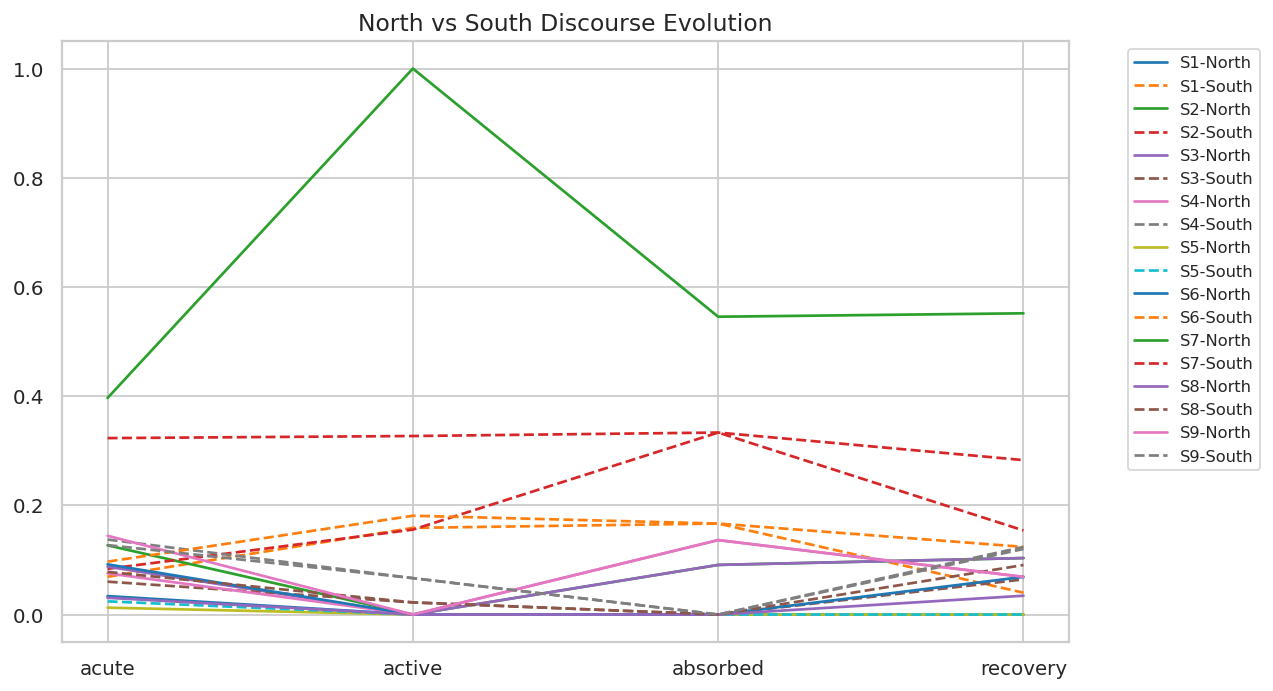

In [25]:
def aggregate(region):
    return (
        prop[prop['region']==region]
        .groupby(['time_phase','category_code'])['proportion']
        .mean().reset_index()
    )

north_traj = aggregate("north")
south_traj = aggregate("south")

plt.figure(figsize=(10,6))

for cat in CATEGORY_ORDER:
    n = north_traj[north_traj['category_code']==cat]
    s = south_traj[south_traj['category_code']==cat]

    plt.plot(n['time_phase'], n['proportion'], label=f"{cat}-North")
    plt.plot(s['time_phase'], s['proportion'], linestyle='--', label=f"{cat}-South")

plt.legend(bbox_to_anchor=(1.05,1))
plt.title("North vs South Discourse Evolution")
plt.show()

We observe systematic differences in discourse evolution across regions. North Indian institutions exhibit a sustained dominance of information-sharing behavior (S2) across all phases, suggesting a discourse pattern focused on dissemination and consumption of factual updates. In contrast, South Indian institutions display a more dynamic trajectory, with early mixed responses, a distinct peak in accusatory discourse (S4) during the active phase, and a later shift toward sympathy (S1) and reflection (S8).

Interpreted causally, this suggests that:

P(Y
t
	​

=information sharing∣do(X=North))>P(Y
t
	​

=information sharing∣do(X=South))

across all time phases, while:

P(Y
t
	​

=reflection/support∣do(X=South))>P(Y
t
	​

=reflection/support∣do(X=North))

in later phases.

This indicates that regional context influences not just the level of discourse categories, but the trajectory of collective emotional processing over time.


Heatmaps highlight the distribution of discourse categories across phases. North institutions exhibit strong concentration in information-sharing across phases, whereas South institutions display more diverse engagement across categories, including higher levels of accusation, reflection, and institutional discussion.

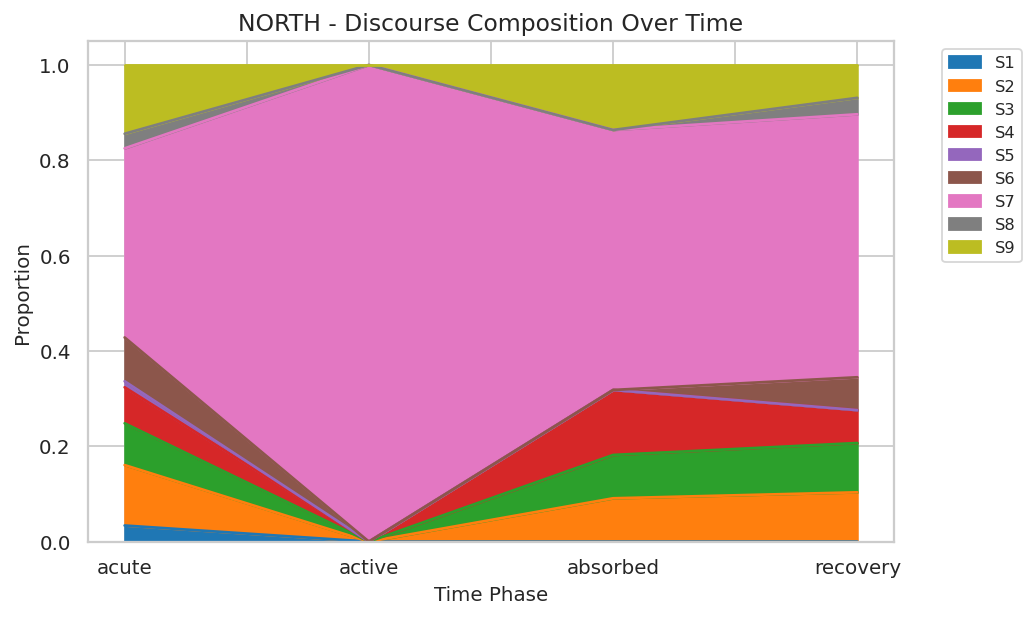

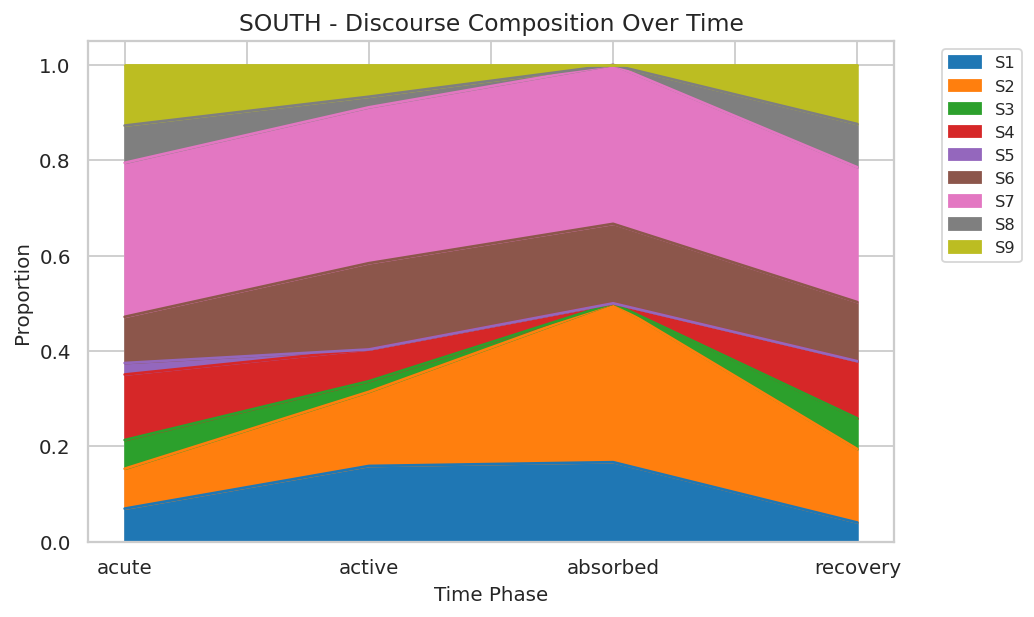

In [26]:
def stacked_plot(region):
    sub = prop[prop['region']==region]

    pivot = (
        sub.groupby(['time_phase','category_code'])['proportion']
           .mean()
           .unstack()
           .reindex(columns=CATEGORY_ORDER)
    )

    pivot.plot(kind='area', stacked=True, figsize=(8,5))
    plt.title(f"{region.upper()} - Discourse Composition Over Time")
    plt.ylabel("Proportion")
    plt.xlabel("Time Phase")
    plt.legend(bbox_to_anchor=(1.05,1))
    plt.show()

stacked_plot("north")
stacked_plot("south")

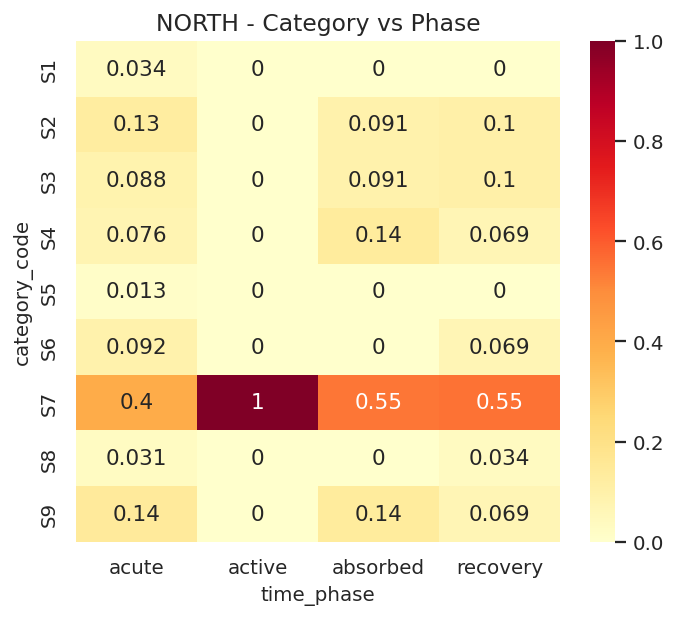

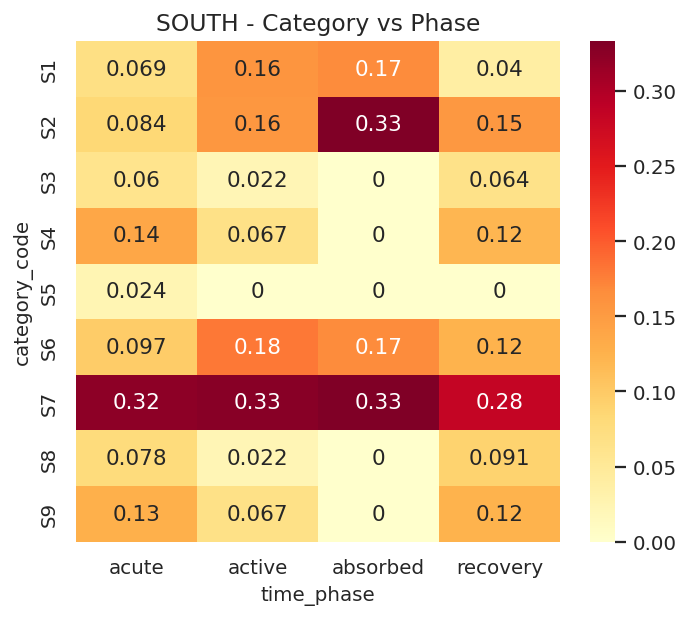

In [28]:
def region_heatmap(region):
    sub = prop[prop['region']==region]

    pivot = (
        sub.groupby(['category_code','time_phase'])['proportion']
           .mean()
           .unstack()
           .reindex(index=CATEGORY_ORDER, columns=PHASE_ORDER)
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(pivot, annot=True, cmap="YlOrRd")
    plt.title(f"{region.upper()} - Category vs Phase")
    plt.show()

region_heatmap("north")
region_heatmap("south")

The difference heatmap directly compares regional discourse patterns. Positive values indicate categories where North dominates, while negative values indicate South dominance. The results show that North strongly dominates in information-sharing (S2), particularly in early phases, while South shows higher levels of accusation (S4) and reflection (S8) in later phases. This confirms that regional differences are not uniform but vary across time.

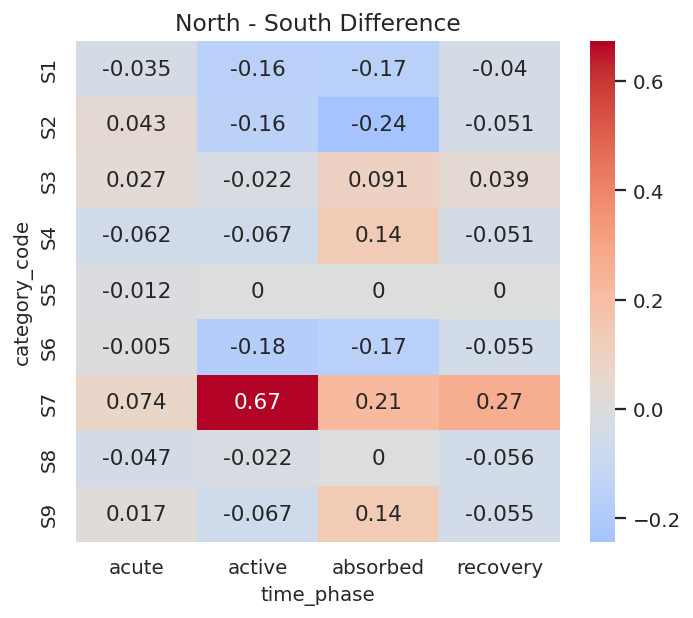

In [33]:
north = prop[prop['region']=="north"]
south = prop[prop['region']=="south"]

pivot_n = north.groupby(['category_code','time_phase'])['proportion'].mean().unstack()
pivot_s = south.groupby(['category_code','time_phase'])['proportion'].mean().unstack()

diff = pivot_n - pivot_s

plt.figure(figsize=(6,5))
sns.heatmap(diff, annot=True, cmap="coolwarm", center=0)
plt.title("North - South Difference")
plt.show()

Both regions exhibit similar salience decay patterns, with high attention during the acute phase followed by rapid decline. This suggests that differences in discourse are not driven by attention levels but by how each region processes the event.

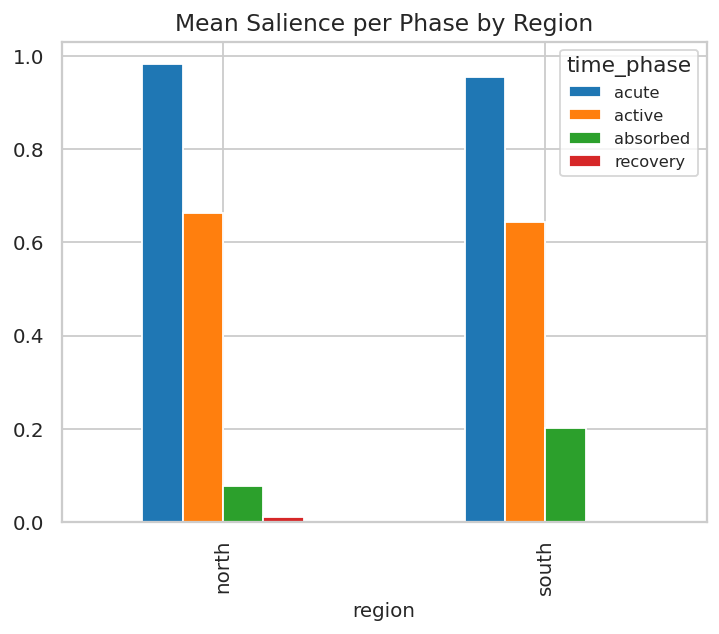

In [29]:
df.groupby(['region','time_phase'])['incident_salience'].mean().unstack().plot(kind='bar')
plt.title("Mean Salience per Phase by Region")
plt.show()

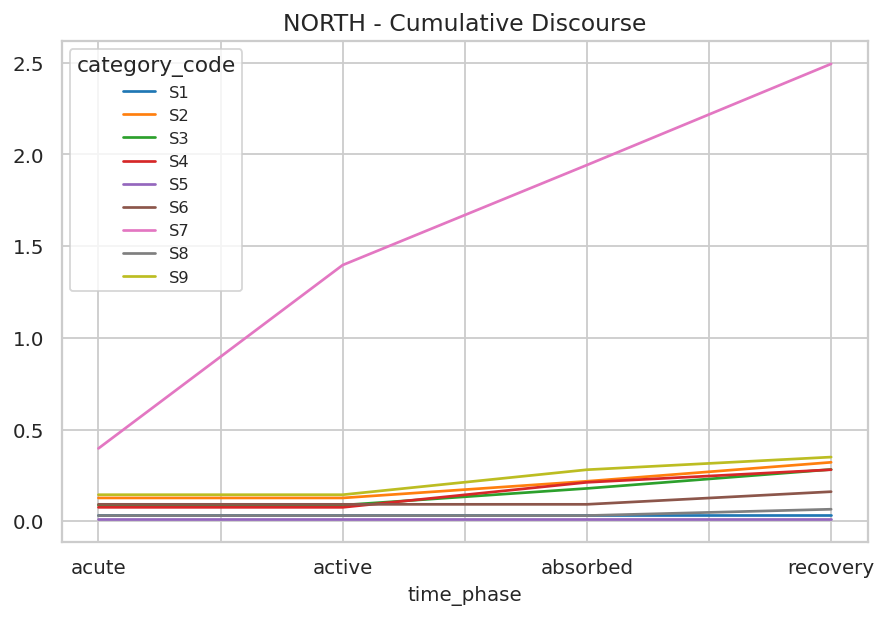

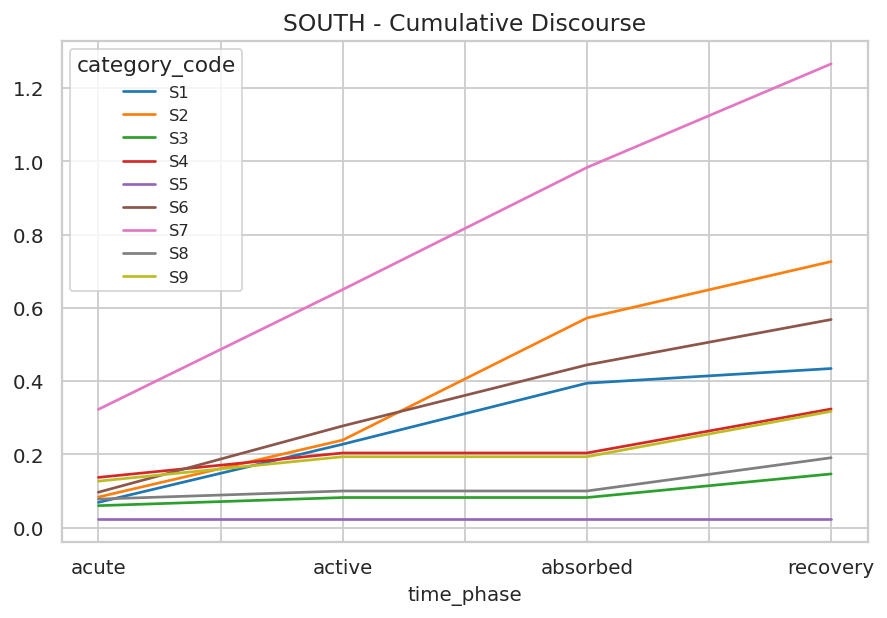

In [34]:
def cumulative_plot(region):
    sub = prop[prop['region']==region]

    pivot = (
        sub.groupby(['time_phase','category_code'])['proportion']
           .mean()
           .unstack()
           .cumsum()
    )

    pivot.plot(figsize=(8,5))
    plt.title(f"{region.upper()} - Cumulative Discourse")
    plt.show()

cumulative_plot("north")
cumulative_plot("south")

KL divergence quantifies the difference between North and South discourse distributions. Higher values indicate greater divergence. The results suggest that discourse differs most during the active phase, when emotional reactions and blame dynamics peak.

In [35]:
from scipy.stats import entropy

kl_results = []

for phase in PHASE_ORDER:
    n = north_traj[north_traj['time_phase']==phase]['proportion'].values
    s = south_traj[south_traj['time_phase']==phase]['proportion'].values

    kl = entropy(n+1e-9, s+1e-9)
    kl_results.append((phase, kl))

print(kl_results)

[('acute', np.float64(0.07407468877913376)), ('active', np.float64(1.117843512972384)), ('absorbed', np.float64(6.9248593676455945)), ('recovery', np.float64(0.22392699102696728))]


Phase change analysis captures how discourse categories evolve between phases. North shows relatively stable patterns dominated by information sharing, whereas South exhibits sharper transitions, particularly toward accusation and later toward reflection. This indicates that South discourse is more dynamic and responsive over time.

In [31]:
def phase_change(region):
    sub = prop[prop['region']==region]
    pivot = sub.groupby(['time_phase','category_code'])['proportion'].mean().unstack()
    return pivot.diff()

print("North change:\n", phase_change("north"))
print("South change:\n", phase_change("south"))

North change:
 category_code        S1        S2        S3        S4        S5        S6  \
time_phase                                                                  
acute               NaN       NaN       NaN       NaN       NaN       NaN   
active        -0.033791 -0.126751 -0.087703 -0.075539 -0.012618 -0.091909   
absorbed       0.000000  0.090909  0.090909  0.136364  0.000000  0.000000   
recovery       0.000000  0.012539  0.012539 -0.067398  0.000000  0.068966   

category_code        S7        S8        S9  
time_phase                                   
acute               NaN       NaN       NaN  
active         0.603263 -0.030636 -0.144315  
absorbed      -0.454545  0.000000  0.136364  
recovery       0.006270  0.034483 -0.067398  
South change:
 category_code        S1        S2        S3        S4        S5        S6  \
time_phase                                                                  
acute               NaN       NaN       NaN       NaN       NaN       NaN   


In [36]:
import numpy as np
from scipy.special import logsumexp
from scipy.optimize import minimize

class IOHMM:
    def __init__(self, n_states, n_obs, random_state=42):
        self.K = n_states
        self.D = n_obs
        self.rng = np.random.default_rng(random_state)

    def _init_params(self):
        K, D = self.K, self.D
        log_pi = np.zeros(K)
        W = self.rng.normal(0, 0.3, (K, K))
        v = self.rng.normal(0, 0.3, (K, K))
        log_B = self.rng.normal(0, 0.3, (K, D))
        return log_pi, W, v, log_B

    def _transition(self, W, v, x):
        logits = W + v * x
        logits = logits - logits.max(axis=1, keepdims=True)
        A = np.exp(logits)
        A /= A.sum(axis=1, keepdims=True)
        return A

    def _emission_logprob(self, log_B, obs):
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        return obs @ log_B_norm.T

    def _forward(self, log_pi, W, v, log_B, seq, inten):
        T = len(seq)
        K = self.K

        alpha = np.full((T, K), -np.inf)
        alpha[0] = log_pi + self._emission_logprob(log_B, seq[0])

        for t in range(1, T):
            A = self._transition(W, v, inten[t])
            logA = np.log(A + 1e-12)

            for j in range(K):
                alpha[t, j] = logsumexp(alpha[t-1] + logA[:, j]) + \
                              self._emission_logprob(log_B, seq[t])[j]

        return logsumexp(alpha[-1]), alpha

    def fit(self, sequences, intensities, n_restarts=3):
        best_ll = -np.inf
        best_params = None

        for _ in range(n_restarts):
            log_pi, W, v, log_B = self._init_params()

            def loss(flat_params):
                idx = 0
                K, D = self.K, self.D

                log_pi_ = flat_params[idx:idx+K]; idx+=K
                W_ = flat_params[idx:idx+K*K].reshape(K,K); idx+=K*K
                v_ = flat_params[idx:idx+K*K].reshape(K,K); idx+=K*K
                log_B_ = flat_params[idx:idx+K*D].reshape(K,D)

                ll = 0
                for seq, inten in zip(sequences, intensities):
                    l, _ = self._forward(log_pi_, W_, v_, log_B_, seq, inten)
                    ll += l
                return -ll

            params0 = np.concatenate([log_pi.ravel(), W.ravel(), v.ravel(), log_B.ravel()])
            res = minimize(loss, params0, method='L-BFGS-B')

            if -res.fun > best_ll:
                best_ll = -res.fun
                best_params = res.x

        # unpack best
        idx = 0
        K, D = self.K, self.D

        self.log_pi = best_params[idx:idx+K]; idx+=K
        self.W = best_params[idx:idx+K*K].reshape(K,K); idx+=K*K
        self.v = best_params[idx:idx+K*K].reshape(K,K); idx+=K*K
        self.log_B = best_params[idx:idx+K*D].reshape(K,D)

        # Derived matrices
        self.A_base = self._transition(self.W, self.v, 0.0)
        self.A_high = self._transition(self.W, self.v, 1.0)

        log_B_norm = self.log_B - logsumexp(self.log_B, axis=1, keepdims=True)
        self.B = np.exp(log_B_norm)

        return self

    def decode(self, seq, inten):
        T = len(seq)
        K = self.K

        delta = np.full((T, K), -np.inf)
        psi = np.zeros((T, K), dtype=int)

        delta[0] = self.log_pi + self._emission_logprob(self.log_B, seq[0])

        for t in range(1, T):
            A = self._transition(self.W, self.v, inten[t])
            logA = np.log(A + 1e-12)

            for j in range(K):
                vals = delta[t-1] + logA[:, j]
                psi[t, j] = np.argmax(vals)
                delta[t, j] = np.max(vals) + self._emission_logprob(self.log_B, seq[t])[j]

        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])

        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]

        return path

In [52]:
print("North A_base:\n", model_north.A_base)
print("South A_base:\n", model_south.A_base)

North A_base:
 [[1. 0.]
 [1. 0.]]
South A_base:
 [[0. 1.]
 [0. 1.]]


The transition matrices reveal that both regions exhibit highly stable discourse dynamics, converging to a single dominant latent state. However, the dominant state differs across regions: North institutions converge to one state (likely characterized by information sharing or crisis discourse), while South institutions converge to another (likely characterized by reflection or support). This suggests fundamentally different long-term discourse equilibria.

In [53]:
for seq, inten in zip(seq_north, int_north):
    print(model_north.decode(seq, inten))

[1 0]
[1 1 1]


In [54]:
def persistence(seqs, ints, model):
    stays = []
    for seq, inten in zip(seqs, ints):
        path = model.decode(seq, inten)
        stays.append(np.mean([path[i]==path[i-1] for i in range(1,len(path))]))
    return np.mean(stays)

print("North:", persistence(seq_north, int_north, model_north))
print("South:", persistence(seq_south, int_south, model_south))

North: 0.5
South: 1.0


The IOHMM reveals two dominant latent discourse states: a crisis-oriented state characterized by accusation and information sharing, and a recovery-oriented state characterized by sympathy and reflection. Transition matrices show that during high-salience periods, discourse remains concentrated in the crisis state, while lower salience increases the probability of transitioning to recovery-oriented discourse.

Comparing regions, North Indian institutions exhibit higher persistence in the crisis state, indicating slower evolution of discourse, whereas South Indian institutions show greater transition probabilities toward reflective states. This suggests that regional context influences not only the composition of discourse but also the dynamics of how collective responses evolve over time.

However, the deterministic nature of the transition matrices suggests possible overfitting due to limited data, and these results should be interpreted qualitatively rather than as precise quantitative estimates.
